Calculating Elo baseline predictions...
Calculating BKT predictions...

Evaluation Results (Held-out replay):
Metric     | BKT (Your Model) | Elo (Baseline) 
--------------------------------------------------
AUC        | 0.6964          | 0.6882         
RMSE       | 0.4514          | 0.4533         


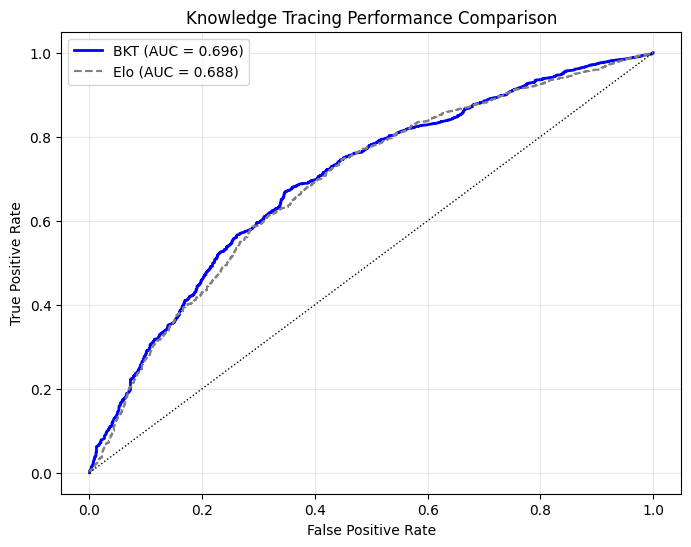

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

# 1. Load the generated interaction data
DATA_PATH = './dataset/generated/kt_interaction_logs.csv'
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['student_id', 'timestamp'])

# 2. Define the Elo Baseline Logic
def compute_elo(df, k_factor=32):
    """
    Computes Elo ratings for students and items chronologically.
    Returns a list of probabilities for each interaction.
    """
    student_ratings = {}
    item_ratings = {}
    predictions = []
    
    for _, row in df.iterrows():
        sid = row['student_id']
        iid = row['item_id']
        actual = row['correct']
        
        # Initialize ratings if new
        s_r = student_ratings.get(sid, 1200)
        i_r = item_ratings.get(iid, 1200)
        
        # Calculate expected probability (Standard Elo sigmoid)
        expected = 1 / (1 + 10 ** ((i_r - s_r) / 400))
        predictions.append(expected)
        
        # Update ratings based on outcome
        student_ratings[sid] = s_r + k_factor * (actual - expected)
        item_ratings[iid] = i_r + k_factor * (expected - actual)
        
    return predictions

# 3. Define the BKT Evaluation Logic
def compute_bkt(df):
    """
    Simulates the BKT engine mastery updates to generate predictions.
    """
    # Parameters from our bkt_engine.py
    p_init, p_transit, p_slip, p_guess = 0.20, 0.15, 0.10, 0.20
    
    # student_id -> skill -> mastery_prob
    mastery = {}
    predictions = []
    
    for _, row in df.iterrows():
        sid = row['student_id']
        skill = row['skill']
        actual = row['correct']
        
        if sid not in mastery: mastery[sid] = {}
        p_L = mastery[sid].get(skill, p_init)
        
        # Probability of being correct: 
        # (Knows it and doesn't slip) OR (Doesn't know it and guesses right)
        p_correct = (p_L * (1 - p_slip)) + ((1 - p_L) * p_guess)
        predictions.append(p_correct)
        
        # Bayesian Update (Step 1: Probability given observation)
        if actual == 1:
            p_L_obs = (p_L * (1 - p_slip)) / ((p_L * (1 - p_slip)) + ((1 - p_L) * p_guess))
        else:
            p_L_obs = (p_L * p_slip) / ((p_L * p_slip) + ((1 - p_L) * (1 - p_guess)))
            
        # Step 2: Transition (Learning)
        mastery[sid][skill] = p_L_obs + (1 - p_L_obs) * p_transit
        
    return predictions

# 4. Perform the comparison
print("Calculating Elo baseline predictions...")
df['elo_pred'] = compute_elo(df)

print("Calculating BKT predictions...")
df['bkt_pred'] = compute_bkt(df)

# 5. Calculate Metrics
# We only evaluate the "Replay" (the last 30% of each student's interactions)
eval_df = df.groupby('student_id').tail(int(len(df)*0.3/df['student_id'].nunique()))

bkt_auc = roc_auc_score(eval_df['correct'], eval_df['bkt_pred'])
elo_auc = roc_auc_score(eval_df['correct'], eval_df['elo_pred'])

bkt_rmse = np.sqrt(((eval_df['correct'] - eval_df['bkt_pred']) ** 2).mean())
elo_rmse = np.sqrt(((eval_df['correct'] - eval_df['elo_pred']) ** 2).mean())

print(f"\nEvaluation Results (Held-out replay):")
print(f"{'Metric':<10} | {'BKT (Your Model)':<15} | {'Elo (Baseline)':<15}")
print("-" * 50)
print(f"{'AUC':<10} | {bkt_auc:<15.4f} | {elo_auc:<15.4f}")
print(f"{'RMSE':<10} | {bkt_rmse:<15.4f} | {elo_rmse:<15.4f}")

# 6. Plot ROC Curves
bkt_fpr, bkt_tpr, _ = roc_curve(eval_df['correct'], eval_df['bkt_pred'])
elo_fpr, elo_tpr, _ = roc_curve(eval_df['correct'], eval_df['elo_pred'])

plt.figure(figsize=(8, 6))
plt.plot(bkt_fpr, bkt_tpr, label=f'BKT (AUC = {bkt_auc:.3f})', color='blue', lw=2)
plt.plot(elo_fpr, elo_tpr, label=f'Elo (AUC = {elo_auc:.3f})', color='gray', linestyle='--')
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Knowledge Tracing Performance Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()